In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Basic states

ket0 = np.array([[1.0 + 0j], [0.0 + 0j]])
ket1 = np.array([[0.0 + 0j], [1.0 + 0j]])

ket_plus = (1 / np.sqrt(2)) * np.array([[1.0 + 0j], [1.0 + 0j]])
ket_minus = (1 / np.sqrt(2)) * np.array([[1.0 + 0j], [-1.0 + 0j]])

ket_plus_i = (1 / np.sqrt(2)) * np.array([[1.0 + 0j], [1.0j]])
ket_minus_i = (1 / np.sqrt(2)) * np.array([[1.0 + 0j], [-1.0j]])

NAMED_STATES = {
    "0": ket0,
    "1": ket1,
    "+": ket_plus,
    "-": ket_minus,
    "+i": ket_plus_i,
    "-i": ket_minus_i,
}

In [3]:
# Gates

I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

def rx(theta):
    return np.cos(theta / 2) * I - 1j * np.sin(theta / 2) * X

def ry(theta):
    return np.cos(theta / 2) * I - 1j * np.sin(theta / 2) * Y

def rz(theta):
    return np.cos(theta / 2) * I - 1j * np.sin(theta / 2) * Z

In [4]:
# Utilities

def normalize(state):
    state = np.asarray(state, dtype=complex).reshape(2, 1)
    norm = np.linalg.norm(state)
    if norm == 0:
        raise ValueError("Statevector has zero norm.")
    return state / norm

def is_unitary(U, tol=1e-9):
    U = np.asarray(U, dtype=complex)
    return U.shape == (2, 2) and np.allclose(U.conj().T @ U, I, atol=tol)

def bloch_vector(state):
    psi = normalize(state)
    x = np.real((psi.conj().T @ X @ psi)[0, 0])
    y = np.real((psi.conj().T @ Y @ psi)[0, 0])
    z = np.real((psi.conj().T @ Z @ psi)[0, 0])
    return np.array([x, y, z], dtype=float)

def format_complex(z, decimals=3):
    return complex(np.round(z.real, decimals), np.round(z.imag, decimals))

def format_state(state, decimals=3):
    psi = normalize(state).flatten()
    a, b = psi[0], psi[1]
    return f"{format_complex(a, decimals)}|0⟩ + {format_complex(b, decimals)}|1⟩"

def spherical_to_state(theta, phi):
    return np.array([
        [np.cos(theta / 2)],
        [np.exp(1j * phi) * np.sin(theta / 2)]
    ], dtype=complex)

In [5]:
# Bloch sphere simulator
# ============================================================

class BlochSphereSimulator:
    def __init__(self, initial_state=ket0):
        self.state = normalize(initial_state)
        self.history = [self.state.copy()]
        self.labels = ["init"]
        self.fig = None
        self.ax = None
        self.path_line = None
        self.vector_artist = None
        self.point_artist = None
        self.text_artist = None
        self.anim = None

    def reset(self, state=ket0, label="reset"):
        self.state = normalize(state)
        self.history = [self.state.copy()]
        self.labels = [label]

    def set_state(self, state, label="set_state"):
        self.state = normalize(state)
        self.history.append(self.state.copy())
        self.labels.append(label)

    def set_named_state(self, name):
        if name not in NAMED_STATES:
            raise ValueError(f"Unknown named state '{name}'. Valid names: {list(NAMED_STATES.keys())}")
        self.set_state(NAMED_STATES[name], label=f"|{name}⟩")

    def apply_unitary(self, U, label="U"):
        U = np.asarray(U, dtype=complex)
        if not is_unitary(U):
            raise ValueError("Input is not a valid 2x2 unitary.")
        self.state = normalize(U @ self.state)
        self.history.append(self.state.copy())
        self.labels.append(label)

    def apply_gate(self, gate_name, theta=None):
        gate_name = gate_name.upper()
        if gate_name == "I":
            self.apply_unitary(I, "I")
        elif gate_name == "X":
            self.apply_unitary(X, "X")
        elif gate_name == "Y":
            self.apply_unitary(Y, "Y")
        elif gate_name == "Z":
            self.apply_unitary(Z, "Z")
        elif gate_name == "H":
            self.apply_unitary(H, "H")
        elif gate_name == "S":
            self.apply_unitary(S, "S")
        elif gate_name == "T":
            self.apply_unitary(T, "T")
        elif gate_name == "RX":
            if theta is None:
                raise ValueError("RX requires theta.")
            self.apply_unitary(rx(theta), f"Rx({theta:.3f})")
        elif gate_name == "RY":
            if theta is None:
                raise ValueError("RY requires theta.")
            self.apply_unitary(ry(theta), f"Ry({theta:.3f})")
        elif gate_name == "RZ":
            if theta is None:
                raise ValueError("RZ requires theta.")
            self.apply_unitary(rz(theta), f"Rz({theta:.3f})")
        else:
            raise ValueError("Unsupported gate name.")

    def measure_z(self, rng=None):
        if rng is None:
            rng = np.random.default_rng()

        psi = normalize(self.state).flatten()
        p0 = float(np.abs(psi[0]) ** 2)
        p1 = float(np.abs(psi[1]) ** 2)

        outcome = 0 if rng.random() < p0 else 1
        collapsed = ket0 if outcome == 0 else ket1

        self.state = collapsed.copy()
        self.history.append(self.state.copy())
        self.labels.append(f"measure Z → {outcome}")

        return outcome, p0, p1

    def print_state(self):
        vec = bloch_vector(self.state)
        print("State:", format_state(self.state))
        print(f"Bloch vector: ({vec[0]:.3f}, {vec[1]:.3f}, {vec[2]:.3f})")

    def _draw_sphere(self, title="Bloch Sphere"):
        self.fig = plt.figure(figsize=(8, 8))
        self.ax = self.fig.add_subplot(111, projection="3d")
        self.ax.set_box_aspect((1, 1, 1))

        u = np.linspace(0, 2 * np.pi, 80)
        v = np.linspace(0, np.pi, 40)
        xs = np.outer(np.cos(u), np.sin(v))
        ys = np.outer(np.sin(u), np.sin(v))
        zs = np.outer(np.ones_like(u), np.cos(v))
        self.ax.plot_surface(xs, ys, zs, alpha=0.08, linewidth=0)

        self.ax.plot([-1, 1], [0, 0], [0, 0], linewidth=1)
        self.ax.plot([0, 0], [-1, 1], [0, 0], linewidth=1)
        self.ax.plot([0, 0], [0, 0], [-1, 1], linewidth=1)

        self.ax.text(1.08, 0, 0, "|+⟩")
        self.ax.text(-1.20, 0, 0, "|-⟩")
        self.ax.text(0, 1.08, 0, "|+i⟩")
        self.ax.text(0, -1.20, 0, "|-i⟩")
        self.ax.text(0, 0, 1.08, "|0⟩")
        self.ax.text(0, 0, -1.18, "|1⟩")

        self.ax.set_xlim([-1.2, 1.2])
        self.ax.set_ylim([-1.2, 1.2])
        self.ax.set_zlim([-1.2, 1.2])
        self.ax.set_title(title)

        self.path_line, = self.ax.plot([], [], [], linewidth=2)
        v0 = bloch_vector(self.history[0])

        self.point_artist = self.ax.scatter([v0[0]], [v0[1]], [v0[2]], s=60)
        self.vector_artist = self.ax.quiver(
            0, 0, 0, v0[0], v0[1], v0[2],
            length=1.0, normalize=False
        )

        self.text_artist = self.ax.text2D(0.02, 0.95, "", transform=self.ax.transAxes)
        self._update_frame(0)

    def _update_frame(self, idx):
        vecs = [bloch_vector(s) for s in self.history[:idx + 1]]
        xs = [v[0] for v in vecs]
        ys = [v[1] for v in vecs]
        zs = [v[2] for v in vecs]

        self.path_line.set_data(xs, ys)
        self.path_line.set_3d_properties(zs)

        current = vecs[-1]

        if self.vector_artist is not None:
            self.vector_artist.remove()

        self.vector_artist = self.ax.quiver(
            0, 0, 0,
            current[0], current[1], current[2],
            length=1.0,
            normalize=False
        )

        self.point_artist._offsets3d = ([current[0]], [current[1]], [current[2]])

        self.text_artist.set_text(
            f"Step {idx}: {self.labels[idx]}\n"
            f"{format_state(self.history[idx])}\n"
            f"Bloch = ({current[0]:.3f}, {current[1]:.3f}, {current[2]:.3f})"
        )

    def show(self, title="Bloch Sphere"):
        self._draw_sphere(title=title)
        plt.show()

    def animate(self, interval=1000, title="Bloch Sphere Animation"):
        self._draw_sphere(title=title)

        def update(frame):
            self._update_frame(frame)
            return self.path_line, self.point_artist, self.vector_artist, self.text_artist

        self.anim = FuncAnimation(
            self.fig,
            update,
            frames=len(self.history),
            interval=interval,
            repeat=False
        )
        plt.show()
        return self.anim

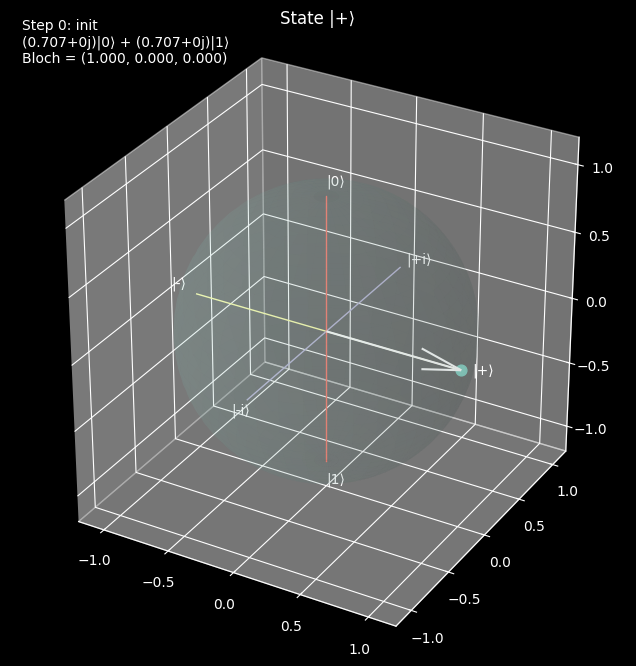

In [7]:
# Show Named state plus
sim = BlochSphereSimulator(ket_plus)
sim.show("State |+⟩")

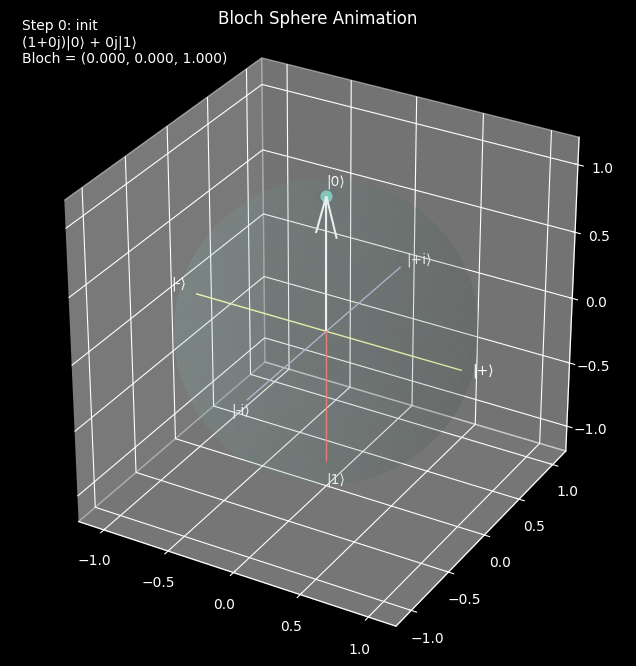

In [9]:
# apply unitary
sim = BlochSphereSimulator(ket0)

U = rz(np.pi / 4) @ ry(np.pi / 3)
sim.apply_unitary(U, label="Custom U")

sim.animate()

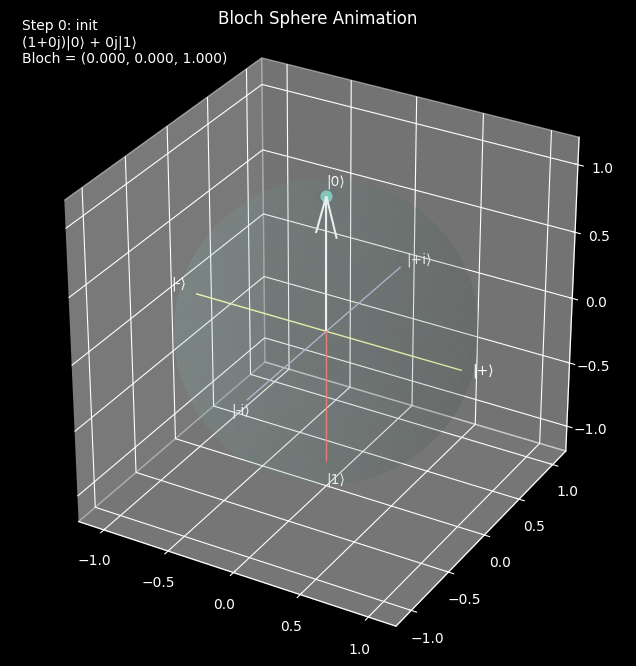

In [10]:
sim = BlochSphereSimulator(ket0)
sim.set_named_state("+")
sim.set_named_state("-")
sim.set_named_state("+i")
sim.set_named_state("-i")
sim.animate(interval=1200)

Outcome: 1
P(0): 0.5000000000000001
P(1): 0.5000000000000001


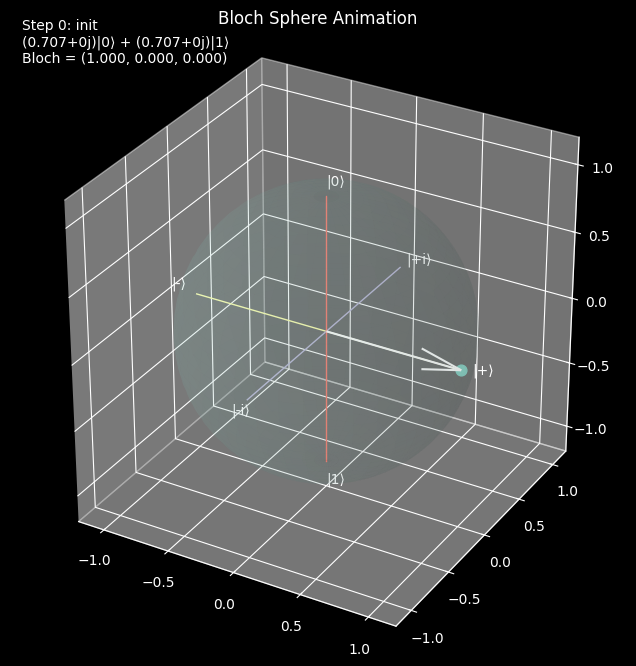

In [11]:
sim = BlochSphereSimulator(ket_plus)
sim.apply_gate("RZ", np.pi / 3)

outcome, p0, p1 = sim.measure_z()
print("Outcome:", outcome)
print("P(0):", p0)
print("P(1):", p1)

sim.animate()